# MMM recovery case study

Fit a constant-intercept MMM, a time-varying-intercept MMM, and the generator's
structure-known reference model to the same simulated observations. Report
contribution error, interval coverage, and sampler diagnostics from the actual
fits, rather than requiring a particular statistical result.

This is one case study, not a recovery guarantee or a calibration benchmark.
The models differ in priors, structural information, and baseline assumptions.
Intervals can miss truth even when chains mix well; poor mixing limits what
can be concluded from the reported intervals.

In [1]:
%matplotlib inline

import os
import tempfile
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import Image, display

from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation

import prior_generator as pg
from prior_generator import viz
from prior_generator.sampler import ADSTOCK_FAMILY_KEYS, SATURATION_FAMILY_KEYS

print('prior-generator', pg.__version__)

prior-generator 0.0.1


## 1 · One causally sufficient world

`sample_scm` uses the configured **maximum sizes**; the active-count ranges
apply to corpus generation, not this single-world API. The direct-edge budget
selects which channels affect sales, so extra channels can have zero direct
effect. Observed controls enter sales directly; latent demand is isolated and
shared baseline/channel innovation strength is zero. These conditions remove
the specified hidden common causes, but do not prove identification from one
finite, potentially collinear time series.

One functional form everywhere, and it is the exact pair the MMM will use:
normalized geometric adstock (`l_max=4`) × Michaelis-Menten saturation.

In [13]:
def pin(adstock, saturation):
    """Family probability dicts that select exactly one family each."""
    return {
        'adstock_family_probs': {**dict.fromkeys(ADSTOCK_FAMILY_KEYS, 0.0), adstock: 1.0},
        'saturation_family_probs': {
            **dict.fromkeys(SATURATION_FAMILY_KEYS, 0.0), saturation: 1.0
        },
    }

cfg = pg.make_scm_prior(
    n_treatments=3, n_covariates=2, n_latent=1, n_time_steps=104, l_max=4,
    n_treatments_active_range=(3, 3), n_covariates_active_range=(2, 2),
    n_latent_active_range=(1, 1),
    edge_budget={'cy': (3, 3), 'zy': (2, 2), 'dy': (0, 0), 'dc': (0, 0),
                 'dz': (0, 0), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0)},
    confounding_strength_range=(0.0, 0.0),   # rho = 0: fully Markovian
    n_cells=2, draws_per_cell=1, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
world = pg.sample_scm(cfg, seed=22, name='sufficient')

# Check structural assumptions, not statistical recovery.
assert world.g['g_cy'].any() and world.g['g_zy'].all()
for name in ('g_dy', 'g_dc', 'g_dz', 'g_zc', 'g_cc', 'g_zz'):
    assert not world.g[name].any(), name
assert float(world.data['confounding_strength']) == 0.0
assert world.identity_error() < 1e-9
print(f'n_time_steps={world.n_time_steps}  active channels={world.n_treatments}'
      f'  direct channels={int(world.g["g_cy"].sum())}'
      f'  controls={world.n_covariates}  latent={world.n_latent} (isolated)')

n_time_steps=104  n_treatments=10 channels  n_covariates=2 controls  n_latent=1 latent (isolated)


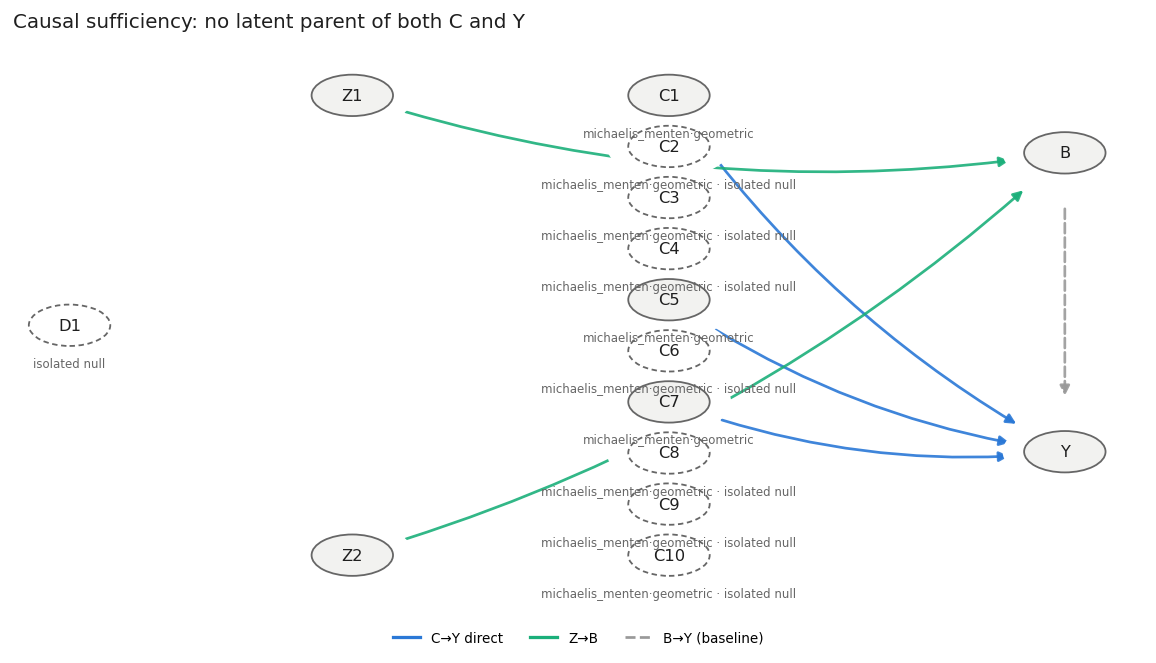

In [14]:
def show(plot_fn, w, title):
    path = os.path.join(tempfile.mkdtemp(), 'fig.png')
    plot_fn(w, path, title)
    display(Image(filename=path))

show(viz.plot_dag, world, 'Causal sufficiency: no latent parent of both C and Y')

The model-facing table is dated spend, controls, and sales — nothing else.
Truth series (`contributions_observed`, `baseline`, the parameters) stay on
our side of the fence, for scoring only.

,date,C1,C2,C3,Z1,Z2,Y
0,2025-01-06,1.873039,0.984453,4.164276,-0.991806,0.298971,9.211697
1,2025-01-13,6.880193,0.862633,4.267417,-0.947913,0.226578,9.343041
2,2025-01-20,3.412878,1.999580,3.772402,-0.892713,0.293091,9.446119
3,2025-01-27,2.494901,0.530230,4.424141,-0.817819,0.306842,9.278026
4,2025-02-03,1.670491,0.190268,8.536763,-0.753368,0.353219,9.274173


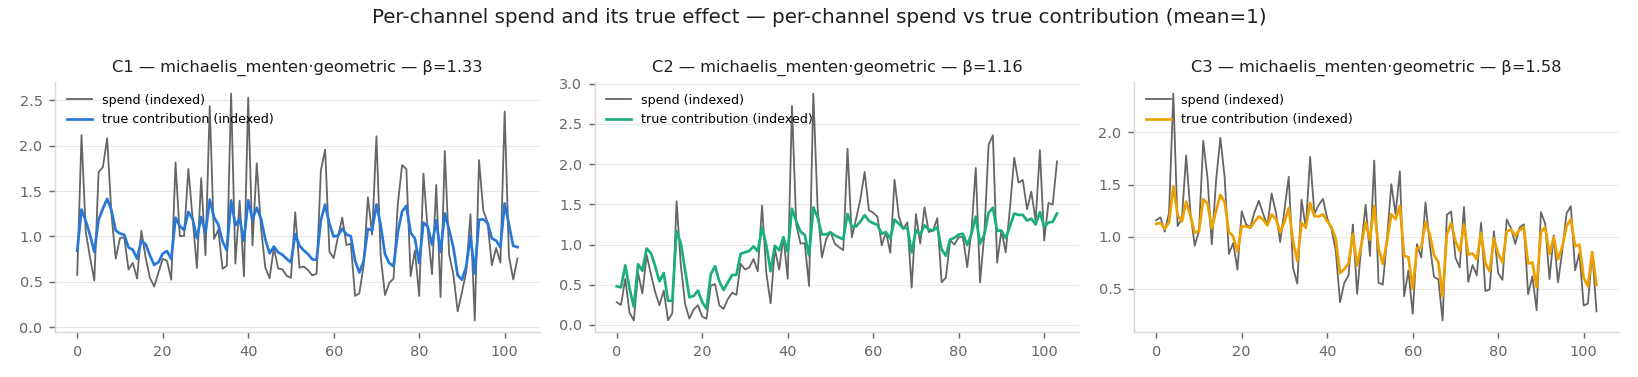

In [4]:
CHANNELS = [f'C{k + 1}' for k in range(world.n_treatments)]
CONTROLS = [f'Z{m + 1}' for m in range(world.n_covariates)]
frame = pd.DataFrame(
    {'date': pd.date_range('2025-01-06', periods=world.n_time_steps, freq='W-MON')}
)
for k, name in enumerate(CHANNELS):
    frame[name] = world.data['channels'][:, k]
for m, name in enumerate(CONTROLS):
    frame[name] = world.data['controls'][:, m]
frame['Y'] = world.data['sales']
X, y = frame.drop(columns='Y'), frame['Y']
display(frame.head())

show(viz.plot_channels, world, 'Per-channel spend and its true effect')

## 2 · The scoring rule, fixed before any model runs

All models are scored on the same reported weeks after the longest carryover
admitted by the reference prior. With this geometric kernel and burn-in,
that excludes the first `l_max - 1` weeks.

- **Cumulative attribution:** posterior median and equal-tailed 94% interval
  for summed contributions, absolute error, and interval coverage.
- **Relative error:** defined only for nonzero truth totals.
- **Weekly shape:** correlation, undefined for constant truth or prediction.

Zero-effect channels remain in the tables with absolute error and coverage.
The oracle knows which channels have zero direct effect; its exact zeros are
structural information, not recovery from the data. Coverage over a few
channels is descriptive, not a test of nominal interval calibration.

The stock MMM fits include their initial zero-padded weeks, while the oracle
likelihood excludes unobserved burn-in influence. This and the different priors
mean the comparison is not a controlled error-model ablation.

In [5]:
from prior_generator.signal_diagnostics import admitted_response_support_weeks

START = (
    admitted_response_support_weeks(
        np.asarray(world.params['adstock_family'])[world.g['g_cy'].astype(bool)],
        cfg.l_max, adstock_alpha_range=cfg.adstock_alpha_range,
    )
    if cfg.adstock_burn_in else 0
)
TRUTH = np.asarray(world.data['contributions_observed'])

def score(samples, dim, label):
    """Score contribution estimates without dividing by a zero truth total."""
    s = samples.isel(date=slice(START, None))
    totals = s.sum('date').quantile([0.03, 0.5, 0.97], dim=('chain', 'draw'))
    mean_path = s.mean(('chain', 'draw'))
    rows = []
    for k, name in enumerate(CHANNELS):
        true_path = TRUTH[START:, k]
        predicted_path = np.asarray(mean_path.sel({dim: name}))
        true_total = float(true_path.sum())
        lo, med, hi = (float(totals.sel({dim: name, 'quantile': q}))
                       for q in (0.03, 0.5, 0.97))
        absolute_error = abs(med - true_total)
        shape_corr = (
            float(np.corrcoef(true_path, predicted_path)[0, 1])
            if np.std(true_path) > 0 and np.std(predicted_path) > 0 else np.nan
        )
        rows.append({
            'model': label, 'channel': name,
            'direct_effect': bool(world.g['g_cy'][k]),
            'true_total': true_total, 'post_median': med,
            'low_94': lo, 'high_94': hi, 'abs_error': absolute_error,
            'rel_error': absolute_error / abs(true_total) if true_total != 0 else np.nan,
            'covered_94': bool(lo <= true_total <= hi), 'shape_corr': shape_corr,
        })
    return pd.DataFrame(rows)

def geometry(idata, label, seconds):
    """Raw finite diagnostics, with undefined entries reported separately.

    Constant deterministics, including known-zero contribution paths, have
    undefined R-hat. Neither their exclusion nor good R-hat proves recovery.
    """
    stats = idata['sample_stats'] if 'sample_stats' in idata else idata.sample_stats
    rhat = az.rhat(idata)
    ess = az.ess(idata, method='bulk')
    rhat_values = np.concatenate([np.asarray(rhat[v]).ravel() for v in rhat.data_vars])
    ess_values = np.concatenate([np.asarray(ess[v]).ravel() for v in ess.data_vars])
    finite_rhat = rhat_values[np.isfinite(rhat_values)]
    finite_ess = ess_values[np.isfinite(ess_values)]
    return {
        'model': label,
        'divergences': int(np.asarray(stats['diverging']).sum()),
        'max_rhat': float(finite_rhat.max()) if finite_rhat.size else np.nan,
        'min_ess_bulk': float(finite_ess.min()) if finite_ess.size else np.nan,
        'undefined_rhat': int((~np.isfinite(rhat_values)).sum()),
        'undefined_ess': int((~np.isfinite(ess_values)).sum()),
        'seconds': float(seconds),
    }

print('scored weeks:', world.n_time_steps - START, 'of', world.n_time_steps)

scored weeks: 100 of 104


## 3 · The stock MMM attempt

The response classes match the generating families and the observed controls
are available. The stock MMM still uses its own default priors and a constant
intercept, unlike the generator's latent baseline walk.

In [6]:
mmm = MMM(
    date_column='date', channel_columns=CHANNELS, control_columns=CONTROLS,
    target_column='Y',
    adstock=GeometricAdstock(l_max=cfg.l_max).set_dims_for_all_priors('channel'),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors('channel'),
)
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(['channel_contribution'])
started = time.perf_counter()
mmm_idata = mmm.fit(X, y, draws=1000, tune=1000, chains=4, cores=4,
                    target_accept=0.9, random_seed=11, progressbar=False)
mmm_geo = geometry(mmm_idata, 'MMM (constant intercept)',
                   time.perf_counter() - started)
print(mmm_geo)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_alpha, gamma_control, y_sigma, intercept_contribution]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Output()

{'model': 'MMM (constant intercept)', 'divergences': 0, 'max_rhat': 1.0027, 'min_ess_bulk': 1845, 'seconds': 8}


In [7]:
mmm_scores = score(
    mmm_idata['posterior']['channel_contribution_original_scale'],
    'channel', 'MMM (constant intercept)',
)
display(mmm_scores.round(3))
print(f"worst cumulative error: {mmm_scores['rel_error'].max():.1%}   "
      f"coverage: {int(mmm_scores['covered_94'].sum())}/{len(CHANNELS)}   "
      f"worst shape corr: {mmm_scores['shape_corr'].min():.3f}")

,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,MMM (constant intercept),C1,55.119,35.078,28.395,45.164,0.364,False,0.984
1,MMM (constant intercept),C2,59.191,70.452,60.789,82.279,0.190,False,1.000
2,MMM (constant intercept),C3,62.895,45.256,35.824,62.404,0.280,False,0.992


worst cumulative error: 36.4%   coverage: 0/3   worst shape corr: 0.984


### Interpreting this fit

Read attribution error and sampler diagnostics separately. High weekly
correlation can coexist with a biased cumulative level. Good R-hat and ESS
address sampling behavior, not model adequacy or identification.

The constant-intercept model cannot represent the generator's baseline walk.
The diagnostics below quantify that omitted variation for this draw; they do
not establish that it alone caused any observed attribution error.

In [8]:
residual_truth = (np.asarray(world.data['baseline_intrinsic'])
                  + np.asarray(world.data['confounder_contribution']).sum(1))[START:]
media_truth = np.asarray(world.data['contributions_observed']).sum(1)[START:]
lag1 = float(np.corrcoef(residual_truth[:-1], residual_truth[1:])[0, 1])

print('what the MMM cannot represent (the intrinsic baseline path):')
print(f'  sd(baseline path) / sd(media)  = {residual_truth.std() / media_truth.std():.2f}')
print(f'  lag-1 autocorrelation          = {lag1:.3f}   (iid noise would be ~0)')
print(f'  share of sales sd              = {residual_truth.std() / np.std(np.asarray(world.data["sales"])[START:]):.2f}')

what the MMM cannot represent (the intrinsic baseline path):
  sd(baseline path) / sd(media)  = 0.33
  lag-1 autocorrelation          = 0.459   (iid noise would be ~0)
  share of sales sd              = 0.16


## 4 · A time-varying-intercept comparison

`time_varying_intercept=True` adds pymc-marketing's HSGP intercept prior.
It allows baseline variation, but is not the same prior as the generating
walk and does not guarantee better attribution or mixing.

In [9]:
mmm_tvi = MMM(
    date_column='date', channel_columns=CHANNELS, control_columns=CONTROLS,
    target_column='Y',
    adstock=GeometricAdstock(l_max=cfg.l_max).set_dims_for_all_priors('channel'),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors('channel'),
    time_varying_intercept=True,
)
mmm_tvi.build_model(X, y)
mmm_tvi.add_original_scale_contribution_variable(['channel_contribution'])
started = time.perf_counter()
tvi_idata = mmm_tvi.fit(X, y, draws=1000, tune=1000, chains=4, cores=4,
                        target_accept=0.9, random_seed=11, progressbar=False)
tvi_geo = geometry(tvi_idata, 'MMM (time-varying intercept)',
                   time.perf_counter() - started)
print(tvi_geo)
tvi_scores = score(
    tvi_idata['posterior']['channel_contribution_original_scale'],
    'channel', 'MMM (time-varying intercept)',
)
display(tvi_scores.round(3))
print(f"worst cumulative error: {tvi_scores['rel_error'].max():.1%}   "
      f"coverage: {int(tvi_scores['covered_94'].sum())}/{len(CHANNELS)}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_alpha, gamma_control, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, y_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

{'model': 'MMM (time-varying intercept)', 'divergences': 1, 'max_rhat': 1.0112, 'min_ess_bulk': 565, 'seconds': 86}


,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,MMM (time-varying intercept),C1,55.119,35.388,28.875,44.523,0.358,False,0.987
1,MMM (time-varying intercept),C2,59.191,58.646,48.043,70.936,0.009,True,1.000
2,MMM (time-varying intercept),C3,62.895,45.975,37.694,56.444,0.269,False,0.994


worst cumulative error: 35.8%   coverage: 1/3


Compare this run's errors, intervals, divergences, R-hat, and ESS with the
constant-intercept fit. A more flexible baseline can trade off with media
effects. Do not infer improvement from model flexibility alone, and do not
interpret poorly mixed intervals as a reliable reference.

## 5 · A structure-known reference posterior

`world.oracle_model()` shares the generator's outcome-side prior definitions
and response functions. It is additionally told the true graph and families,
including direct-null channels. By default it integrates the unfloored
Gaussian demand and baseline paths, adding iid observation-noise variance.

This is a plug-in model of sales given observed spend and controls, not the
complete joint posterior over their generation. In this isolated-demand,
zero-shared-innovation case, the specified input-confounding paths are absent.
Even here, finite data and overlapping signal patterns can leave parameters
uncertain. The fit is a reference, not a certificate of identification.

In [10]:
oracle = world.oracle_model()
print('free parameters:', sorted(rv.name for rv in oracle.free_RVs))
started = time.perf_counter()
with oracle:
    oracle_idata = pm.sample(draws=1000, tune=1000, chains=4, cores=4,
                             target_accept=0.9, random_seed=11,
                             progressbar=False)
oracle_geo = geometry(oracle_idata, 'oracle (marginal)',
                      time.perf_counter() - started)
print(oracle_geo)

free parameters: ['adstock_alpha', 'beta', 'delta_db', 'mm_kappa_mult', 'rho_zb', 'rw_b_mean', 'rw_b_std_rel', 'rw_y_std_rel']


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [rw_b_mean, rw_b_std_rel, rw_y_std_rel, beta, delta_db, rho_zb, adstock_alpha, mm_kappa_mult]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


{'model': 'oracle (marginal)', 'divergences': 1, 'max_rhat': 1.0037, 'min_ess_bulk': 1428, 'seconds': 49}


In [11]:
oracle_contrib = (
    oracle_idata.posterior['contributions']
    .rename({'contributions_dim_0': 'date', 'contributions_dim_1': 'channel'})
    .assign_coords(channel=CHANNELS, date=np.arange(world.n_time_steps))
)
oracle_scores = score(oracle_contrib, 'channel', 'oracle (marginal)')
display(oracle_scores.round(3))
print(f"worst cumulative error: {oracle_scores['rel_error'].max():.1%}   "
      f"coverage: {int(oracle_scores['covered_94'].sum())}/{len(CHANNELS)}")

if (not np.isfinite(oracle_geo['max_rhat'])
        or oracle_geo['max_rhat'] >= 1.01 or oracle_geo['divergences'] > 0):
    print('Oracle diagnostics require review; its intervals are not a reliable recovery verdict.')
if oracle_geo['undefined_rhat'] or oracle_geo['undefined_ess']:
    print('Some diagnostics are undefined, including structurally constant quantities; inspect them.')

,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,oracle (marginal),C1,55.119,54.104,45.375,66.603,0.018,True,0.997
1,oracle (marginal),C2,59.191,59.630,50.912,68.982,0.007,True,1.000
2,oracle (marginal),C3,62.895,67.646,59.529,78.718,0.076,True,1.000


worst cumulative error: 7.6%   coverage: 3/3


Report parameter intervals as well. Parameters of direct-null channels do not
enter this oracle's sales likelihood: their intervals are prior-only, not
evidence of parameter recovery.

In [12]:
rows = []
for name in ('beta', 'adstock_alpha', 'mm_kappa_mult'):
    truth_values = np.asarray(world.params[name])
    draws = oracle_idata.posterior[name]
    mean = np.asarray(draws.mean(('chain', 'draw')))
    lo = np.asarray(draws.quantile(0.03, dim=('chain', 'draw')))
    hi = np.asarray(draws.quantile(0.97, dim=('chain', 'draw')))
    for k, channel in enumerate(CHANNELS):
        rows.append({'parameter': name, 'channel': channel,
                     'in_likelihood': bool(world.g['g_cy'][k]),
                     'true': truth_values[k], 'post_mean': mean[k],
                     'low_94': lo[k], 'high_94': hi[k],
                     'covered': bool(lo[k] <= truth_values[k] <= hi[k])})
recovered = pd.DataFrame(rows)
display(recovered.round(3))
informed = recovered.loc[recovered['in_likelihood']]
print('likelihood-active parameter coverage:', int(informed['covered'].sum()), '/', len(informed))
print('prior-only parameter rows:', int((~recovered['in_likelihood']).sum()))

,parameter,channel,true,post_mean,low_94,high_94,covered
0,beta,C1,1.332,1.258,1.082,1.449,True
1,beta,C2,1.157,1.191,1.033,1.367,True
2,beta,C3,1.575,1.639,1.439,1.869,True
3,adstock_alpha,C1,0.412,0.348,0.248,0.448,True
4,adstock_alpha,C2,0.272,0.293,0.215,0.378,True
5,adstock_alpha,C3,0.241,0.260,0.205,0.341,True
6,mm_kappa_mult,C1,1.368,1.256,0.839,1.491,True
7,mm_kappa_mult,C2,0.857,0.906,0.711,1.258,True
8,mm_kappa_mult,C3,1.435,1.348,1.033,1.496,True


parameter coverage: 9 / 9


## 6 · Side by side

In [13]:
summary = pd.concat([mmm_scores, tvi_scores, oracle_scores], ignore_index=True)
coverage = summary.groupby('model')['covered_94'].sum().astype(int)
geo = pd.DataFrame([mmm_geo, tvi_geo, oracle_geo]).set_index('model')
table = pd.DataFrame({
    'worst rel error': summary.groupby('model')['rel_error'].max(),
    'median rel error': summary.groupby('model')['rel_error'].median(),
    'worst absolute error': summary.groupby('model')['abs_error'].max(),
    f'covered / {len(CHANNELS)}': coverage,
    f'direct covered / {int(world.g["g_cy"].sum())}': (
        summary.loc[summary['direct_effect']].groupby('model')['covered_94'].sum().astype(int)
    ),
    'divergences': geo['divergences'],
    'max r-hat': geo['max_rhat'],
    'min ESS': geo['min_ess_bulk'],
    'undefined R-hat': geo['undefined_rhat'],
    'undefined ESS': geo['undefined_ess'],
})
display(table.round(3))

,worst rel error,median rel error,covered / 3,divergences,max r-hat,min ESS
model,,,,,,
MMM (constant intercept),0.364,0.280,0,0,1.003,1845
MMM (time-varying intercept),0.358,0.269,1,1,1.011,565
oracle (marginal),0.076,0.018,3,1,1.004,1428


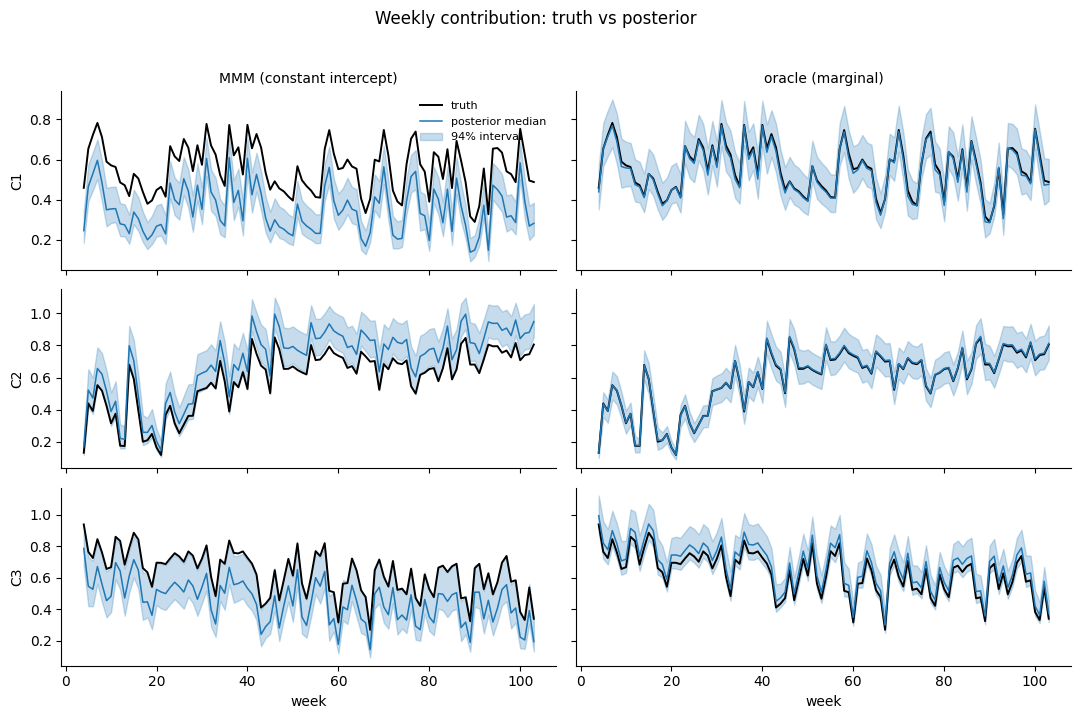

In [14]:
quantiles = {
    'MMM (constant intercept)': mmm_idata['posterior']['channel_contribution_original_scale'],
    'oracle (marginal)': oracle_contrib,
}
weeks = np.arange(world.n_time_steps)[START:]
fig, axes = plt.subplots(
    world.n_treatments, len(quantiles), figsize=(11, 2.6 * world.n_treatments),
    sharex=True, sharey='row', squeeze=False,
)
for col, (label, samples) in enumerate(quantiles.items()):
    s = samples.isel(date=slice(START, None))
    q = s.quantile([0.03, 0.5, 0.97], dim=('chain', 'draw'))
    for k, channel in enumerate(CHANNELS):
        ax = axes[k, col]
        ax.plot(weeks, TRUTH[START:, k], color='black', lw=1.4, label='truth')
        ax.plot(weeks, q.sel(channel=channel, quantile=0.5), color='C0', lw=1.1,
                label='posterior median')
        ax.fill_between(weeks, q.sel(channel=channel, quantile=0.03),
                        q.sel(channel=channel, quantile=0.97), color='C0', alpha=0.25,
                        label='94% interval')
        ax.spines[['top', 'right']].set_visible(False)
        if k == 0:
            ax.set_title(label, fontsize=10)
        if col == 0:
            ax.set_ylabel(channel)
axes[0, 0].legend(frameon=False, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('week')
fig.suptitle('Weekly contribution: truth vs posterior', y=1.02)
fig.tight_layout()
plt.show()

Rows share their y-axis across models. Compare interval level, width, and
weekly shape separately. A zero-width oracle band on a direct-null channel
comes from the supplied graph, not from learning that channel's effect.

## 7 · What to take away

- **Report what happened, not an expected success.** The tables contain this
  run's errors, coverage, and diagnostics. No error threshold or coverage
  count is asserted as a property of the generator.
- **Separate sampling from recovery.** Convergence diagnostics do not certify
  identification, adequate priors, or a correct error model. Poor diagnostics
  also prevent treating the fitted reference as definitive.
- **Separate structural information from data.** The oracle knows the graph;
  the stock MMM does not. Known-zero effects and prior-only shape parameters
  must not be counted as evidence that the data identified those quantities.
- **One draw is not a benchmark.** Multi-world calibration and controlled
  comparisons are needed before attributing a performance gap to one modeling
  choice. See the [data-generation tour](index.ipynb) and
  [oracle assumptions](../guide/oracle.md).